In [1]:
## what do we want?
## regions with choice decoding
## look at overlap with prior and stimulus to see if it changes

In [3]:
%load_ext autoreload
%autoreload 2

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from iblatlas.atlas import BrainRegions
from one.api import ONE
from brainbox.population.decode import get_spike_counts_in_bins
from brainbox.io.one import SpikeSortingLoader, SessionLoader
from brainbox.ephys_plots import plot_brain_regions
from brainbox.task.trials import get_event_aligned_raster, get_psth
from iblatlas.atlas import AllenAtlas
from brainbox.behavior.training import compute_performance, plot_psychometric, plot_reaction_time
from brainbox.task.trials import find_trial_ids
from brainbox.io.one import SessionLoader
from brainbox.population.decode import get_spike_counts_in_bins
from pathlib import Path
from brainbox.task.trials import get_event_aligned_raster, get_psth
from brainbox import singlecell
from tqdm.notebook import tqdm
import seaborn as sns

from iblatlas.atlas import AllenAtlas
from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units
from brainwidemap.bwm_loading import merge_probes
from brainbox.behavior.training import compute_performance, plot_psychometric, plot_reaction_time
from brainbox.io.one import SessionLoader
from pathlib import Path
from brainbox.task.trials import get_event_aligned_raster, get_psth
from brainbox.singlecell import bin_spikes2D
import numpy as np
from iblatlas.atlas import BrainRegions
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import itertools
import pickle as pkl
from tqdm import tqdm
from pathlib import Path
import warnings
from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units

In [2]:
# df_granger = pd.read_csv("../data/processed/granger.csv")
# df_decoding_session_choice = pd.read_parquet("../data/external/choice_stage2.pqt")
# df_decoding_session_stim = pd.read_parquet("../data/external/stimside_stage2.pqt")
# df_decoding_session_feedback = pd.read_parquet("../data/external/feedback_stage2.pqt")
df_decoding_region = pd.read_csv("../data/external/region_info.csv")

In [3]:
important_columns = [
    "Beryl",
    "Beryl.1",
    "# recordings",
    "# neurons",
    "# good neurons",
    "stim_dec",
    "stim_dec_sig",
    "choice_dec",
    "choice_dec_sig",
    "prior_dec_ep",
    "prior_dec_ep_sig",
    "prior_dec_wf_sig",
]

In [4]:
df = df_decoding_region[important_columns]

In [10]:
df_with_prior_stim = df[(df["prior_dec_ep_sig"] == True) & (df["stim_dec_sig"] == True)]
df_with_choice = df[df["choice_dec_sig"] == True]

In [16]:
df_with_choice_overlap = df[
    (df["choice_dec_sig"] == True)
    & (df["prior_dec_ep_sig"] == True)
    & (df["stim_dec_sig"] == True)
]

In [ ]:
# just look at overlap then :yeah
# choice interval is what?
# only thing we change

In [7]:
ONE.setup(base_url="https://openalyx.internationalbrainlab.org", silent=True)
one = ONE(password="international")

bwm_df = bwm_query(one)
unit_df = bwm_units(one)

Connected to https://openalyx.internationalbrainlab.org as user "intbrainlab"
Loading bwm_query results from fixtures/2023_12_bwm_release.csv
Loading bwm_query results from fixtures/2023_12_bwm_release.csv
d16d0b38d392b18c0ce8b615ec89d60d7c901df2eeb3432986b62130af28ef01


In [26]:
regions_of_interest = df_with_choice_overlap["Beryl"].unique()
units_regions_of_interest = unit_df[unit_df["Beryl"].isin(regions_of_interest)]

In [28]:
# load up a eid and check

In [5]:
subject_id = "CSH_ZAD_022"
eid = "a82800ce-f4e3-4464-9b80-4c3d6fade333"
session_id = eid

session_id = eid
# pids, probes = one.eid2pid(session_id)
# if isinstance(probes, list) and len(probes) > 1:
#     to_merge = [load_good_units(one, pid=pid, qc=1) for pid in pids]
#     spikes, clusters = merge_probes(
#         [spikes for spikes, _ in to_merge], [clusters for _, clusters in to_merge]
#     )
# else:
#     spikes, clusters = load_good_units(one, pid=pids[0], qc=1)

In [40]:
ss = SessionLoader(one, eid=session_id)
ss.load_trials()

In [10]:
trials, mask = load_trials_and_mask(
    one, session_id, exclude_nochoice=False, exclude_unbiased=False
)
trials = trials[mask]

In [24]:
plt.style.use("../figures.style")

Text(0, 0.5, '$\\mathtt{P_{Left}}$')

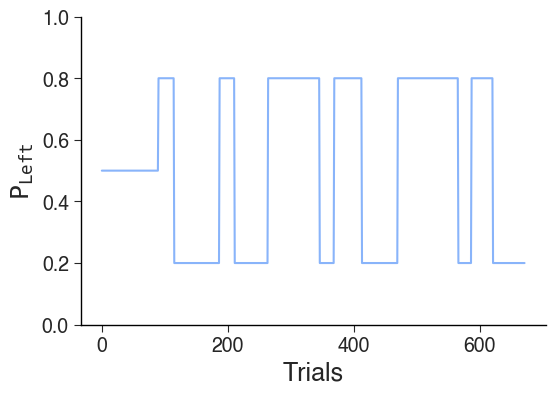

In [41]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ss.trials["probabilityLeft"])
ax.set_ylim(0, 1)
sns.despine()
ax.set_xlabel("Trials")
ax.set_ylabel("$\mathtt{P_{Left}}$")

Text(0, 0.5, '$\\mathtt{P_{Left}}$')

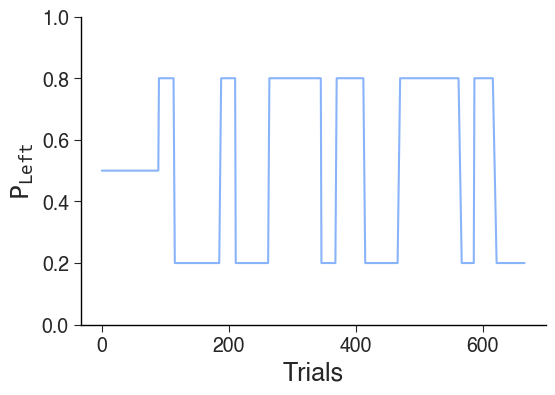

In [36]:
left_stim = trials.contrastLeft >= 0
right_stim = trials.contrastRight >= 0

In [40]:
from ibl_info.prepare_data_pid import get_new_cinc_intervals_choice

In [60]:
intervals, choice_side, conflags, inconflags = get_new_cinc_intervals_choice(trials)

In [70]:
intervals[conflags][:15]

array([[628.98236653, 629.18236653],
       [635.46736653, 635.66736653],
       [638.28236653, 638.48236653],
       [641.05136653, 641.25136653],
       [653.01736653, 653.21736653],
       [656.51436653, 656.71436653],
       [659.33836653, 659.53836653],
       [681.29736653, 681.49736653],
       [697.48936653, 697.68936653],
       [704.64336653, 704.84336653],
       [707.70536653, 707.90536653],
       [736.90536653, 737.10536653],
       [770.39336653, 770.59336653],
       [779.91636653, 780.11636653],
       [786.90636653, 787.10636653]])